In [8]:
import numpy as np
import pandas as pd
import os
import gc
import warnings
warnings.filterwarnings('ignore')

In [9]:
# ---- LOAD SUBSAMPLED SPATIAL DATASET ----
data_path = r"D:\\Important\\Semester\\Semester X\\MTP\\LSI\\shimla_subsampled_spatial.parquet"

print("Loading subsampled spatial dataset...")
df = pd.read_parquet(data_path)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Loading subsampled spatial dataset...
Shape: (999995, 19)
Columns: ['pixel_row', 'pixel_col', 'landslide_dist', 'slope', 'lulc', 'elevation', 'road_dist', 'builtup_dist', 'land_value', 'water_dist', 'lineament_dist', 'lst', 'railway_dist', 'lsi_continuous', 'lsi_classified', 'block_row', 'block_col', 'block_id', 'split']


In [10]:
# ---- DEFINE FEATURE AND TARGET COLUMNS ----
feature_cols = ["landslide_dist", "slope", "lulc", "elevation", "road_dist",
                "builtup_dist", "land_value", "water_dist", "lineament_dist",
                "lst", "railway_dist"]

# ---- SEPARATE BY SPLIT ----
train = df[df["split"] == "train"]
val = df[df["split"] == "val"]
test = df[df["split"] == "test"]

X_train = train[feature_cols]
X_val = val[feature_cols]
X_test = test[feature_cols]

Y_train_cls = train["lsi_classified"].astype(int)
Y_val_cls = val["lsi_classified"].astype(int)
Y_test_cls = test["lsi_classified"].astype(int)

Y_train_reg = train["lsi_continuous"]
Y_val_reg = val["lsi_continuous"]
Y_test_reg = test["lsi_continuous"]

# ---- VERIFY ----
print(f"\nSplit sizes:")
print(f"  Train: X={X_train.shape}, Y_cls={Y_train_cls.shape}, Y_reg={Y_train_reg.shape}")
print(f"  Val:   X={X_val.shape}, Y_cls={Y_val_cls.shape}, Y_reg={Y_val_reg.shape}")
print(f"  Test:  X={X_test.shape}, Y_cls={Y_test_cls.shape}, Y_reg={Y_test_reg.shape}")

print(f"\nClass distribution in train:")
class_labels = {1: "Very Low", 2: "Low", 3: "Moderate", 4: "High", 5: "Very High"}
for cls, count in Y_train_cls.value_counts().sort_index().items():
    pct = (count / len(Y_train_cls)) * 100
    print(f"  {cls} ({class_labels[cls]:<10}): {count:>8,} ({pct:.2f}%)")

# ---- FREE MEMORY ----
del df, train, val, test
gc.collect()
print("\nData loaded and ready for training.")


Split sizes:
  Train: X=(699998, 11), Y_cls=(699998,), Y_reg=(699998,)
  Val:   X=(149999, 11), Y_cls=(149999,), Y_reg=(149999,)
  Test:  X=(149998, 11), Y_cls=(149998,), Y_reg=(149998,)

Class distribution in train:
  1 (Very Low  ):   13,951 (1.99%)
  2 (Low       ):  175,181 (25.03%)
  3 (Moderate  ):  416,199 (59.46%)
  4 (High      ):   77,779 (11.11%)
  5 (Very High ):   16,888 (2.41%)

Data loaded and ready for training.


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             classification_report, confusion_matrix)
import time

In [12]:
# ---- TRAIN RANDOM FOREST CLASSIFIER ----
print("Training Random Forest Classifier...")
print("=" * 50)

start_time = time.time()

rf_cls = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',      # handles class imbalance
    random_state=42,
    n_jobs=-1,                    # use all CPU cores
    verbose=1
)

rf_cls.fit(X_train, Y_train_cls)
train_time = time.time() - start_time
print(f"\nTraining time: {train_time:.1f} seconds")

# ---- PREDICT ON VALIDATION SET ----
print("\n" + "=" * 50)
print("VALIDATION SET RESULTS")
print("=" * 50)

val_pred = rf_cls.predict(X_val)

val_accuracy = accuracy_score(Y_val_cls, val_pred)
val_f1 = f1_score(Y_val_cls, val_pred, average='weighted')
val_kappa = cohen_kappa_score(Y_val_cls, val_pred)

print(f"\nAccuracy:  {val_accuracy:.4f}")
print(f"Weighted F1: {val_f1:.4f}")
print(f"Kappa:     {val_kappa:.4f}")

print(f"\nClassification Report:")
print(classification_report(Y_val_cls, val_pred, 
                            target_names=["Very Low", "Low", "Moderate", "High", "Very High"]))

print(f"Confusion Matrix:")
cm = confusion_matrix(Y_val_cls, val_pred)
print(pd.DataFrame(cm, 
                    index=[f"True {class_labels[i]}" for i in range(1,6)],
                    columns=[f"Pred {class_labels[i]}" for i in range(1,6)]))


Training Random Forest Classifier...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   56.7s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  1.6min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s



Training time: 94.6 seconds

VALIDATION SET RESULTS


[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.4s



Accuracy:  0.9472
Weighted F1: 0.9472
Kappa:     0.9047

Classification Report:
              precision    recall  f1-score   support

    Very Low       0.88      0.81      0.85      3246
         Low       0.92      0.94      0.93     36730
    Moderate       0.97      0.96      0.96     92003
        High       0.89      0.94      0.92     15825
   Very High       0.98      0.84      0.90      2195

    accuracy                           0.95    149999
   macro avg       0.93      0.90      0.91    149999
weighted avg       0.95      0.95      0.95    149999

Confusion Matrix:
                Pred Very Low  Pred Low  Pred Moderate  Pred High  \
True Very Low            2634       612              0          0   
True Low                  348     34373           2009          0   
True Moderate               0      2269          88314       1420   
True High                   0         0            868      14923   
True Very High              0         0              0        361  

[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.7s finished


In [13]:
# ---- PREDICT ON TEST SET ----
print("\n" + "=" * 50)
print("TEST SET RESULTS")
print("=" * 50)

test_pred = rf_cls.predict(X_test)

test_accuracy = accuracy_score(Y_test_cls, test_pred)
test_f1 = f1_score(Y_test_cls, test_pred, average='weighted')
test_kappa = cohen_kappa_score(Y_test_cls, test_pred)

print(f"\nAccuracy:  {test_accuracy:.4f}")
print(f"Weighted F1: {test_f1:.4f}")
print(f"Kappa:     {test_kappa:.4f}")

print(f"\nClassification Report:")
print(classification_report(Y_test_cls, test_pred,
                            target_names=["Very Low", "Low", "Moderate", "High", "Very High"]))

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.



TEST SET RESULTS


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.4s



Accuracy:  0.9468
Weighted F1: 0.9469
Kappa:     0.9097

Classification Report:
              precision    recall  f1-score   support

    Very Low       0.86      0.80      0.83      2901
         Low       0.93      0.93      0.93     35369
    Moderate       0.97      0.96      0.96     87563
        High       0.88      0.95      0.92     16714
   Very High       1.00      0.88      0.93      7451

    accuracy                           0.95    149998
   macro avg       0.93      0.90      0.91    149998
weighted avg       0.95      0.95      0.95    149998



[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.7s finished


In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [15]:
# ---- TRAIN RANDOM FOREST REGRESSOR ----
print("Training Random Forest Regressor...")
print("=" * 50)

start_time = time.time()

rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_reg.fit(X_train, Y_train_reg)
train_time = time.time() - start_time
print(f"\nTraining time: {train_time:.1f} seconds")

# ---- VALIDATION RESULTS ----
print("\n" + "=" * 50)
print("VALIDATION SET RESULTS")
print("=" * 50)

val_pred_reg = rf_reg.predict(X_val)
print(f"R² Score:  {r2_score(Y_val_reg, val_pred_reg):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(Y_val_reg, val_pred_reg)):.4f}")
print(f"MAE:       {mean_absolute_error(Y_val_reg, val_pred_reg):.4f}")

# ---- TEST RESULTS ----
print("\n" + "=" * 50)
print("TEST SET RESULTS")
print("=" * 50)

test_pred_reg = rf_reg.predict(X_test)
print(f"R² Score:  {r2_score(Y_test_reg, test_pred_reg):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(Y_test_reg, test_pred_reg)):.4f}")
print(f"MAE:       {mean_absolute_error(Y_test_reg, test_pred_reg):.4f}")

# ---- PREDICTION RANGE CHECK ----
print(f"\nPrediction range: {test_pred_reg.min():.4f} to {test_pred_reg.max():.4f}")
print(f"Actual range:     {Y_test_reg.min():.4f} to {Y_test_reg.max():.4f}")

# ---- FEATURE IMPORTANCE ----
print("\n" + "=" * 50)
print("FEATURE IMPORTANCE (Random Forest)")
print("=" * 50)

importances = rf_reg.feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "RF_Importance": importances
}).sort_values("RF_Importance", ascending=False)

# Add AHP weights for comparison
ahp_weights = {
    "landslide_dist": 0.162, "slope": 0.138, "lulc": 0.122,
    "elevation": 0.114, "road_dist": 0.095, "builtup_dist": 0.084,
    "land_value": 0.079, "water_dist": 0.061, "lineament_dist": 0.056,
    "lst": 0.048, "railway_dist": 0.041
}
importance_df["AHP_Weight"] = importance_df["Feature"].map(ahp_weights)

print(f"\n{'Feature':<18} {'RF Importance':>14} {'AHP Weight':>12} {'Rank Diff':>10}")
print("-" * 56)
for i, row in importance_df.iterrows():
    rf_rank = list(importance_df["Feature"]).index(row["Feature"]) + 1
    ahp_rank = list(importance_df.sort_values("AHP_Weight", ascending=False)["Feature"]).index(row["Feature"]) + 1
    diff = ahp_rank - rf_rank
    print(f"{row['Feature']:<18} {row['RF_Importance']:>14.4f} {row['AHP_Weight']:>12.3f} {diff:>+10d}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


Training Random Forest Regressor...


[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   21.3s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  3.6min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s



Training time: 214.0 seconds

VALIDATION SET RESULTS


[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.5s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.9s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s


R² Score:  0.9788
RMSE:      0.0446
MAE:       0.0224

TEST SET RESULTS


[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.4s


R² Score:  0.9762
RMSE:      0.0539
MAE:       0.0236

Prediction range: 2.0869 to 4.6543
Actual range:     2.0830 to 4.9930

FEATURE IMPORTANCE (Random Forest)

Feature             RF Importance   AHP Weight  Rank Diff
--------------------------------------------------------
landslide_dist             0.1906        0.162         +0
road_dist                  0.1604        0.095         +3
land_value                 0.1513        0.079         +4
slope                      0.1436        0.138         -2
elevation                  0.1080        0.114         -1
builtup_dist               0.0965        0.084         +0
lineament_dist             0.0909        0.056         +2
water_dist                 0.0249        0.061         +0
lst                        0.0219        0.048         +1
lulc                       0.0082        0.122         -7
railway_dist               0.0039        0.041         +0


[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.8s finished


In [16]:
from xgboost import XGBClassifier, XGBRegressor

# ============================================================
# XGBOOST CLASSIFIER
# ============================================================
print("Training XGBoost Classifier...")
print("=" * 50)

start_time = time.time()

xgb_cls = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    verbosity=1,
    eval_metric='mlogloss'
)

xgb_cls.fit(X_train, Y_train_cls - 1)  # XGBoost needs 0-indexed classes
train_time = time.time() - start_time
print(f"Training time: {train_time:.1f} seconds")

# ---- VALIDATION ----
print("\n" + "=" * 50)
print("XGBOOST CLASSIFIER — VALIDATION")
print("=" * 50)

xgb_val_pred = xgb_cls.predict(X_val) + 1  # convert back to 1-indexed

val_accuracy = accuracy_score(Y_val_cls, xgb_val_pred)
val_f1 = f1_score(Y_val_cls, xgb_val_pred, average='weighted')
val_kappa = cohen_kappa_score(Y_val_cls, xgb_val_pred)

print(f"Accuracy:    {val_accuracy:.4f}")
print(f"Weighted F1: {val_f1:.4f}")
print(f"Kappa:       {val_kappa:.4f}")

print(f"\nClassification Report:")
print(classification_report(Y_val_cls, xgb_val_pred,
                            target_names=["Very Low", "Low", "Moderate", "High", "Very High"]))

# ---- TEST ----
print("=" * 50)
print("XGBOOST CLASSIFIER — TEST")
print("=" * 50)

xgb_test_pred = xgb_cls.predict(X_test) + 1

test_accuracy = accuracy_score(Y_test_cls, xgb_test_pred)
test_f1 = f1_score(Y_test_cls, xgb_test_pred, average='weighted')
test_kappa = cohen_kappa_score(Y_test_cls, xgb_test_pred)

print(f"Accuracy:    {test_accuracy:.4f}")
print(f"Weighted F1: {test_f1:.4f}")
print(f"Kappa:       {test_kappa:.4f}")

print(f"\nClassification Report:")
print(classification_report(Y_test_cls, xgb_test_pred,
                            target_names=["Very Low", "Low", "Moderate", "High", "Very High"]))


Training XGBoost Classifier...
Training time: 31.2 seconds

XGBOOST CLASSIFIER — VALIDATION
Accuracy:    0.9727
Weighted F1: 0.9724
Kappa:       0.9501

Classification Report:
              precision    recall  f1-score   support

    Very Low       0.96      0.82      0.88      3246
         Low       0.96      0.96      0.96     36730
    Moderate       0.98      0.99      0.98     92003
        High       0.97      0.95      0.96     15825
   Very High       0.99      0.91      0.95      2195

    accuracy                           0.97    149999
   macro avg       0.97      0.92      0.95    149999
weighted avg       0.97      0.97      0.97    149999

XGBOOST CLASSIFIER — TEST
Accuracy:    0.9695
Weighted F1: 0.9692
Kappa:       0.9478

Classification Report:
              precision    recall  f1-score   support

    Very Low       0.97      0.81      0.88      2901
         Low       0.97      0.96      0.96     35369
    Moderate       0.98      0.99      0.98     87563
        

In [17]:
# ============================================================
# XGBOOST REGRESSOR
# ============================================================
print("=" * 50)
print("Training XGBoost Regressor...")
print("=" * 50)

start_time = time.time()

xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

xgb_reg.fit(X_train, Y_train_reg)
train_time = time.time() - start_time
print(f"Training time: {train_time:.1f} seconds")

# ---- VALIDATION ----
xgb_val_reg_pred = xgb_reg.predict(X_val)
print(f"\nValidation:")
print(f"  R² Score: {r2_score(Y_val_reg, xgb_val_reg_pred):.4f}")
print(f"  RMSE:     {np.sqrt(mean_squared_error(Y_val_reg, xgb_val_reg_pred)):.4f}")
print(f"  MAE:      {mean_absolute_error(Y_val_reg, xgb_val_reg_pred):.4f}")

# ---- TEST ----
xgb_test_reg_pred = xgb_reg.predict(X_test)
print(f"\nTest:")
print(f"  R² Score: {r2_score(Y_test_reg, xgb_test_reg_pred):.4f}")
print(f"  RMSE:     {np.sqrt(mean_squared_error(Y_test_reg, xgb_test_reg_pred)):.4f}")
print(f"  MAE:      {mean_absolute_error(Y_test_reg, xgb_test_reg_pred):.4f}")

# ---- XGBOOST FEATURE IMPORTANCE ----
print("\n" + "=" * 50)
print("FEATURE IMPORTANCE COMPARISON (RF vs XGBoost vs AHP)")
print("=" * 50)

xgb_importances = xgb_reg.feature_importances_
importance_df["XGB_Importance"] = [xgb_importances[feature_cols.index(f)] for f in importance_df["Feature"]]

# Re-sort by RF importance
importance_df = importance_df.sort_values("RF_Importance", ascending=False)

print(f"\n{'Feature':<18} {'RF':>8} {'XGB':>8} {'AHP':>8}")
print("-" * 44)
for _, row in importance_df.iterrows():
    print(f"{row['Feature']:<18} {row['RF_Importance']:>8.4f} {row['XGB_Importance']:>8.4f} {row['AHP_Weight']:>8.3f}")

Training XGBoost Regressor...
Training time: 5.9 seconds

Validation:
  R² Score: 0.9948
  RMSE:     0.0220
  MAE:      0.0136

Test:
  R² Score: 0.9885
  RMSE:     0.0375
  MAE:      0.0146

FEATURE IMPORTANCE COMPARISON (RF vs XGBoost vs AHP)

Feature                  RF      XGB      AHP
--------------------------------------------
landslide_dist       0.1906   0.1409    0.162
road_dist            0.1604   0.1383    0.095
land_value           0.1513   0.1107    0.079
slope                0.1436   0.1790    0.138
elevation            0.1080   0.0932    0.114
builtup_dist         0.0965   0.0950    0.084
lineament_dist       0.0909   0.0864    0.056
water_dist           0.0249   0.0365    0.061
lst                  0.0219   0.0308    0.048
lulc                 0.0082   0.0442    0.122
railway_dist         0.0039   0.0448    0.041


In [12]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# ---- FEATURE SCALING (required for SVM) ----
print("Scaling features for SVM...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("  Scaling complete.")

# ---- TRAIN SVM CLASSIFIER ----
# Using smaller subsample for SVM (it's very slow on large data)
print("\nSubsampling for SVM (100K train)...")
np.random.seed(42)
svm_idx = np.random.choice(len(X_train_scaled), size=100_000, replace=False)
X_train_svm = X_train_scaled[svm_idx]
Y_train_svm = Y_train_cls.iloc[svm_idx]

print(f"SVM training size: {len(X_train_svm):,}")

print("\nTraining SVM Classifier (this may take a few minutes)...")
print("=" * 50)

start_time = time.time()

svm_cls = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    random_state=42,
    verbose=False
)

svm_cls.fit(X_train_svm, Y_train_svm)
train_time = time.time() - start_time
print(f"Training time: {train_time:.1f} seconds")

# ---- VALIDATION ----
print("\n" + "=" * 50)
print("SVM CLASSIFIER — VALIDATION")
print("=" * 50)

svm_val_pred = svm_cls.predict(X_val_scaled)
print(f"Accuracy:    {accuracy_score(Y_val_cls, svm_val_pred):.4f}")
print(f"Weighted F1: {f1_score(Y_val_cls, svm_val_pred, average='weighted'):.4f}")
print(f"Kappa:       {cohen_kappa_score(Y_val_cls, svm_val_pred):.4f}")

print(f"\nClassification Report:")
print(classification_report(Y_val_cls, svm_val_pred,
                            target_names=["Very Low", "Low", "Moderate", "High", "Very High"]))

# ---- TEST ----
print("=" * 50)
print("SVM CLASSIFIER — TEST")
print("=" * 50)

svm_test_pred = svm_cls.predict(X_test_scaled)
print(f"Accuracy:    {accuracy_score(Y_test_cls, svm_test_pred):.4f}")
print(f"Weighted F1: {f1_score(Y_test_cls, svm_test_pred, average='weighted'):.4f}")
print(f"Kappa:       {cohen_kappa_score(Y_test_cls, svm_test_pred):.4f}")

print(f"\nClassification Report:")
print(classification_report(Y_test_cls, svm_test_pred,
                            target_names=["Very Low", "Low", "Moderate", "High", "Very High"]))

# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================
print("\n" + "=" * 60)
print("COMPLETE MODEL COMPARISON (Test Set — Spatial Split)")
print("=" * 60)
print(f"\n{'Metric':<20} {'RF':>10} {'XGBoost':>10} {'SVM':>10}")
print("-" * 52)
print(f"{'Accuracy':<20} {'0.9468':>10} {'0.9695':>10} {accuracy_score(Y_test_cls, svm_test_pred):>10.4f}")
print(f"{'Weighted F1':<20} {'0.9469':>10} {'0.9692':>10} {f1_score(Y_test_cls, svm_test_pred, average='weighted'):>10.4f}")
print(f"{'Kappa':<20} {'0.9097':>10} {'0.9478':>10} {cohen_kappa_score(Y_test_cls, svm_test_pred):>10.4f}")

Scaling features for SVM...
  Scaling complete.

Subsampling for SVM (100K train)...
SVM training size: 100,000

Training SVM Classifier (this may take a few minutes)...
Training time: 244.8 seconds

SVM CLASSIFIER — VALIDATION
Accuracy:    0.7859
Weighted F1: 0.7941
Kappa:       0.6475

Classification Report:
              precision    recall  f1-score   support

    Very Low       0.46      0.88      0.61      3246
         Low       0.71      0.81      0.76     36730
    Moderate       0.93      0.76      0.83     92003
        High       0.55      0.87      0.68     15825
   Very High       0.81      0.84      0.82      2195

    accuracy                           0.79    149999
   macro avg       0.69      0.83      0.74    149999
weighted avg       0.83      0.79      0.79    149999

SVM CLASSIFIER — TEST
Accuracy:    0.7973
Weighted F1: 0.8048
Kappa:       0.6824

Classification Report:
              precision    recall  f1-score   support

    Very Low       0.44      0.89     

In [9]:
# ============================================================
# STEP 5: RANDOM SPLIT COMPARISON
# ============================================================
print("=" * 60)
print("RANDOM SPLIT — SPATIAL LEAKAGE ANALYSIS")
print("=" * 60)

RANDOM SPLIT — SPATIAL LEAKAGE ANALYSIS


In [10]:
# ---- LOAD RANDOM SPLIT DATASET ----
rand_path = r"D:\\Important\\Semester\\Semester X\\MTP\\LSI\\shimla_subsampled_random.parquet"
df_rand = pd.read_parquet(rand_path)
print(f"Random dataset shape: {df_rand.shape}")

# ---- SEPARATE SPLITS ----
rand_train = df_rand[df_rand["split"] == "train"]
rand_val = df_rand[df_rand["split"] == "val"]
rand_test = df_rand[df_rand["split"] == "test"]

X_train_r = rand_train[feature_cols]
X_val_r = rand_val[feature_cols]
X_test_r = rand_test[feature_cols]

Y_train_cls_r = rand_train["lsi_classified"].astype(int)
Y_val_cls_r = rand_val["lsi_classified"].astype(int)
Y_test_cls_r = rand_test["lsi_classified"].astype(int)

Y_train_reg_r = rand_train["lsi_continuous"]
Y_test_reg_r = rand_test["lsi_continuous"]

print(f"Train: {X_train_r.shape[0]:,} | Val: {X_val_r.shape[0]:,} | Test: {X_test_r.shape[0]:,}")


Random dataset shape: (1000000, 19)
Train: 700,000 | Val: 150,000 | Test: 150,000


In [13]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             classification_report, confusion_matrix)
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [14]:
# ============================================================
# RANDOM FOREST — RANDOM SPLIT
# ============================================================
print("\n" + "=" * 60)
print("RANDOM FOREST — RANDOM SPLIT")
print("=" * 60)

start_time = time.time()
rf_cls_r = RandomForestClassifier(
    n_estimators=300, max_depth=20, min_samples_split=10,
    min_samples_leaf=5, class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=0
)
rf_cls_r.fit(X_train_r, Y_train_cls_r)
rf_time_r = time.time() - start_time

rf_test_pred_r = rf_cls_r.predict(X_test_r)
rf_acc_r = accuracy_score(Y_test_cls_r, rf_test_pred_r)
rf_f1_r = f1_score(Y_test_cls_r, rf_test_pred_r, average='weighted')
rf_kappa_r = cohen_kappa_score(Y_test_cls_r, rf_test_pred_r)

print(f"Training time: {rf_time_r:.1f}s")
print(f"Accuracy:    {rf_acc_r:.4f}")
print(f"Weighted F1: {rf_f1_r:.4f}")
print(f"Kappa:       {rf_kappa_r:.4f}")
print(f"\nClassification Report:")
print(classification_report(Y_test_cls_r, rf_test_pred_r,
                            target_names=["Very Low", "Low", "Moderate", "High", "Very High"]))

# RF Regressor — Random Split
rf_reg_r = RandomForestRegressor(
    n_estimators=300, max_depth=20, min_samples_split=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1, verbose=0
)
rf_reg_r.fit(X_train_r, Y_train_reg_r)
rf_reg_pred_r = rf_reg_r.predict(X_test_r)
rf_r2_r = r2_score(Y_test_reg_r, rf_reg_pred_r)
rf_rmse_r = np.sqrt(mean_squared_error(Y_test_reg_r, rf_reg_pred_r))
print(f"Regression — R²: {rf_r2_r:.4f}, RMSE: {rf_rmse_r:.4f}")


RANDOM FOREST — RANDOM SPLIT
Training time: 94.3s
Accuracy:    0.9658
Weighted F1: 0.9659
Kappa:       0.9381

Classification Report:
              precision    recall  f1-score   support

    Very Low       0.88      0.91      0.89      3092
         Low       0.95      0.96      0.95     37966
    Moderate       0.98      0.97      0.98     91818
        High       0.93      0.98      0.95     17042
   Very High       0.84      0.83      0.83        82

    accuracy                           0.97    150000
   macro avg       0.92      0.93      0.92    150000
weighted avg       0.97      0.97      0.97    150000

Regression — R²: 0.9879, RMSE: 0.0322


In [15]:
# ============================================================
# XGBOOST — RANDOM SPLIT
# ============================================================
print("\n" + "=" * 60)
print("XGBOOST — RANDOM SPLIT")
print("=" * 60)

start_time = time.time()
xgb_cls_r = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=42, n_jobs=-1, verbosity=0, eval_metric='mlogloss'
)
xgb_cls_r.fit(X_train_r, Y_train_cls_r - 1)
xgb_time_r = time.time() - start_time

xgb_test_pred_r = xgb_cls_r.predict(X_test_r) + 1
xgb_acc_r = accuracy_score(Y_test_cls_r, xgb_test_pred_r)
xgb_f1_r = f1_score(Y_test_cls_r, xgb_test_pred_r, average='weighted')
xgb_kappa_r = cohen_kappa_score(Y_test_cls_r, xgb_test_pred_r)

print(f"Training time: {xgb_time_r:.1f}s")
print(f"Accuracy:    {xgb_acc_r:.4f}")
print(f"Weighted F1: {xgb_f1_r:.4f}")
print(f"Kappa:       {xgb_kappa_r:.4f}")
print(f"\nClassification Report:")
print(classification_report(Y_test_cls_r, xgb_test_pred_r,
                            target_names=["Very Low", "Low", "Moderate", "High", "Very High"]))

# XGB Regressor — Random Split
xgb_reg_r = XGBRegressor(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_reg_r.fit(X_train_r, Y_train_reg_r)
xgb_reg_pred_r = xgb_reg_r.predict(X_test_r)
xgb_r2_r = r2_score(Y_test_reg_r, xgb_reg_pred_r)
xgb_rmse_r = np.sqrt(mean_squared_error(Y_test_reg_r, xgb_reg_pred_r))
print(f"Regression — R²: {xgb_r2_r:.4f}, RMSE: {xgb_rmse_r:.4f}")


XGBOOST — RANDOM SPLIT
Training time: 35.1s
Accuracy:    0.9827
Weighted F1: 0.9827
Kappa:       0.9684

Classification Report:
              precision    recall  f1-score   support

    Very Low       0.97      0.90      0.94      3092
         Low       0.98      0.97      0.97     37966
    Moderate       0.98      0.99      0.99     91818
        High       0.99      0.97      0.98     17042
   Very High       0.92      0.79      0.85        82

    accuracy                           0.98    150000
   macro avg       0.97      0.93      0.95    150000
weighted avg       0.98      0.98      0.98    150000

Regression — R²: 0.9954, RMSE: 0.0199


In [16]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [17]:
# ============================================================
# SVM — RANDOM SPLIT
# ============================================================
print("\n" + "=" * 60)
print("SVM — RANDOM SPLIT")
print("=" * 60)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

# Subsample for SVM
np.random.seed(42)
svm_idx_r = np.random.choice(len(X_train_r_scaled), size=100_000, replace=False)

start_time = time.time()
svm_cls_r = SVC(
    kernel='rbf', C=10, gamma='scale',
    class_weight='balanced', random_state=42, verbose=False
)
svm_cls_r.fit(X_train_r_scaled[svm_idx_r], Y_train_cls_r.iloc[svm_idx_r])
svm_time_r = time.time() - start_time

svm_test_pred_r = svm_cls_r.predict(X_test_r_scaled)
svm_acc_r = accuracy_score(Y_test_cls_r, svm_test_pred_r)
svm_f1_r = f1_score(Y_test_cls_r, svm_test_pred_r, average='weighted')
svm_kappa_r = cohen_kappa_score(Y_test_cls_r, svm_test_pred_r)

print(f"Training time: {svm_time_r:.1f}s")
print(f"Accuracy:    {svm_acc_r:.4f}")
print(f"Weighted F1: {svm_f1_r:.4f}")
print(f"Kappa:       {svm_kappa_r:.4f}")
print(f"\nClassification Report:")
print(classification_report(Y_test_cls_r, svm_test_pred_r,
                            target_names=["Very Low", "Low", "Moderate", "High", "Very High"]))



SVM — RANDOM SPLIT
Training time: 325.3s
Accuracy:    0.7960
Weighted F1: 0.8030
Kappa:       0.6630

Classification Report:
              precision    recall  f1-score   support

    Very Low       0.49      0.92      0.64      3092
         Low       0.73      0.84      0.78     37966
    Moderate       0.94      0.75      0.84     91818
        High       0.58      0.92      0.71     17042
   Very High       0.28      0.77      0.41        82

    accuracy                           0.80    150000
   macro avg       0.60      0.84      0.68    150000
weighted avg       0.84      0.80      0.80    150000



In [18]:
# ============================================================
# SPATIAL vs RANDOM — COMPLETE COMPARISON
# ============================================================
print("\n" + "=" * 70)
print("SPATIAL vs RANDOM SPLIT — COMPLETE COMPARISON (Test Set)")
print("=" * 70)

print(f"\n{'':>20} {'--- SPATIAL SPLIT ---':>30} {'--- RANDOM SPLIT ---':>30}")
print(f"{'Metric':<20} {'RF':>8} {'XGB':>8} {'SVM':>8} {'RF':>8} {'XGB':>8} {'SVM':>8}")
print("-" * 70)
print(f"{'Accuracy':<20} {'0.9468':>8} {'0.9695':>8} {'0.7973':>8} {rf_acc_r:>8.4f} {xgb_acc_r:>8.4f} {svm_acc_r:>8.4f}")
print(f"{'Weighted F1':<20} {'0.9469':>8} {'0.9692':>8} {'0.8048':>8} {rf_f1_r:>8.4f} {xgb_f1_r:>8.4f} {svm_f1_r:>8.4f}")
print(f"{'Kappa':<20} {'0.9097':>8} {'0.9478':>8} {'0.6824':>8} {rf_kappa_r:>8.4f} {xgb_kappa_r:>8.4f} {svm_kappa_r:>8.4f}")

print(f"\n{'--- ACCURACY GAP (Random - Spatial) ---':>50}")
print(f"{'RF Gap':<20} {rf_acc_r - 0.9468:>+8.4f}")
print(f"{'XGB Gap':<20} {xgb_acc_r - 0.9695:>+8.4f}")
print(f"{'SVM Gap':<20} {svm_acc_r - 0.7973:>+8.4f}")

print(f"\n{'--- REGRESSION COMPARISON ---':>40}")
print(f"{'':>20} {'Spatial':>15} {'Random':>15}")
print(f"{'RF R²':<20} {'0.9762':>15} {rf_r2_r:>15.4f}")
print(f"{'XGB R²':<20} {'0.9885':>15} {xgb_r2_r:>15.4f}")
print(f"{'RF RMSE':<20} {'0.0539':>15} {rf_rmse_r:>15.4f}")
print(f"{'XGB RMSE':<20} {'0.0375':>15} {xgb_rmse_r:>15.4f}")

# ---- CLEANUP ----
del df_rand, rand_train, rand_val, rand_test
del rf_cls_r, rf_reg_r, xgb_cls_r, xgb_reg_r, svm_cls_r
gc.collect()


SPATIAL vs RANDOM SPLIT — COMPLETE COMPARISON (Test Set)

                              --- SPATIAL SPLIT ---           --- RANDOM SPLIT ---
Metric                     RF      XGB      SVM       RF      XGB      SVM
----------------------------------------------------------------------
Accuracy               0.9468   0.9695   0.7973   0.9658   0.9827   0.7960
Weighted F1            0.9469   0.9692   0.8048   0.9659   0.9827   0.8030
Kappa                  0.9097   0.9478   0.6824   0.9381   0.9684   0.6630

           --- ACCURACY GAP (Random - Spatial) ---
RF Gap                +0.0190
XGB Gap               +0.0132
SVM Gap               -0.0013

           --- REGRESSION COMPARISON ---
                             Spatial          Random
RF R²                         0.9762          0.9879
XGB R²                        0.9885          0.9954
RF RMSE                       0.0539          0.0322
XGB RMSE                      0.0375          0.0199


454

# SHAP

In [1]:
import numpy as np
import pandas as pd
import os
import gc
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             classification_report, r2_score,
                             mean_squared_error, mean_absolute_error)
from xgboost import XGBClassifier, XGBRegressor

# ---- LOAD DATA ----
data_path = r"D:\\Important\\Semester\\Semester X\\MTP\\LSI\\shimla_subsampled_spatial.parquet"
df = pd.read_parquet(data_path)
df["lulc"] = df["lulc"].astype(np.int8)

# ---- DEFINE COLUMNS ----
feature_cols = ["landslide_dist", "slope", "lulc", "elevation", "road_dist",
                "builtup_dist", "land_value", "water_dist", "lineament_dist",
                "lst", "railway_dist"]

class_labels = {1: "Very Low", 2: "Low", 3: "Moderate", 4: "High", 5: "Very High"}

# ---- SEPARATE SPLITS ----
train = df[df["split"] == "train"]
val = df[df["split"] == "val"]
test = df[df["split"] == "test"]

X_train = train[feature_cols]
X_val = val[feature_cols]
X_test = test[feature_cols]

Y_train_cls = train["lsi_classified"].astype(int)
Y_val_cls = val["lsi_classified"].astype(int)
Y_test_cls = test["lsi_classified"].astype(int)

Y_train_reg = train["lsi_continuous"]
Y_val_reg = val["lsi_continuous"]
Y_test_reg = test["lsi_continuous"]

del df, train, val, test
gc.collect()

print(f"Data loaded: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")

# ---- RETRAIN XGBOOST REGRESSOR (needed for SHAP) ----
print("\nRetraining XGBoost Regressor...")
xgb_reg = XGBRegressor(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_reg.fit(X_train, Y_train_reg)

test_pred = xgb_reg.predict(X_test)
print(f"XGBoost Regressor R²: {r2_score(Y_test_reg, test_pred):.4f}")

# ---- RETRAIN XGBOOST CLASSIFIER (needed later) ----
print("\nRetraining XGBoost Classifier...")
xgb_cls = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=42, n_jobs=-1, verbosity=0, eval_metric='mlogloss'
)
xgb_cls.fit(X_train, Y_train_cls - 1)

xgb_test_pred = xgb_cls.predict(X_test) + 1
print(f"XGBoost Classifier Kappa: {cohen_kappa_score(Y_test_cls, xgb_test_pred):.4f}")

print("\n✓ Session restored. Ready for SHAP analysis.")

Data loaded: Train=(699998, 11), Val=(149999, 11), Test=(149998, 11)

Retraining XGBoost Regressor...
XGBoost Regressor R²: 0.9885

Retraining XGBoost Classifier...
XGBoost Classifier Kappa: 0.9478

✓ Session restored. Ready for SHAP analysis.


In [2]:
import shap

print("=" * 60)
print("STEP 6: FEATURE IMPORTANCE & SHAP ANALYSIS")
print("=" * 60)

# ---- USE SPATIAL SPLIT XGBOOST REGRESSOR ----
# (xgb_reg was trained earlier on spatial split)

# SHAP on full dataset is slow, so we use a subsample
print("\nPreparing SHAP analysis on XGBoost Regressor (spatial split)...")
np.random.seed(42)
shap_sample_idx = np.random.choice(len(X_test), size=5000, replace=False)
X_shap = X_test.iloc[shap_sample_idx]

print(f"SHAP sample size: {len(X_shap):,}")

# ---- COMPUTE SHAP VALUES ----
print("Computing SHAP values (this may take 1-2 minutes)...")
explainer = shap.TreeExplainer(xgb_reg)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP computation complete.")

# ---- SHAP SUMMARY STATISTICS ----
print("\n" + "=" * 60)
print("MEAN ABSOLUTE SHAP VALUES (Feature Impact Ranking)")
print("=" * 60)

mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    "Feature": feature_cols,
    "Mean_SHAP": mean_shap
}).sort_values("Mean_SHAP", ascending=False)

# Add AHP and RF importance for comparison
ahp_weights = {
    "landslide_dist": 0.162, "slope": 0.138, "lulc": 0.122,
    "elevation": 0.114, "road_dist": 0.095, "builtup_dist": 0.084,
    "land_value": 0.079, "water_dist": 0.061, "lineament_dist": 0.056,
    "lst": 0.048, "railway_dist": 0.041
}
shap_df["AHP_Weight"] = shap_df["Feature"].map(ahp_weights)

# Normalize SHAP to sum to 1 for direct comparison
shap_df["SHAP_Normalized"] = shap_df["Mean_SHAP"] / shap_df["Mean_SHAP"].sum()

print(f"\n{'Rank':<6} {'Feature':<18} {'SHAP (norm)':>12} {'AHP Weight':>12} {'Agreement':>12}")
print("-" * 62)
for rank, (_, row) in enumerate(shap_df.iterrows(), 1):
    ahp_rank = list(pd.DataFrame(ahp_weights, index=[0]).T.sort_values(0, ascending=False).index).index(row["Feature"]) + 1
    diff = abs(rank - ahp_rank)
    agreement = "✓ Match" if diff <= 1 else f"↕ {diff} ranks"
    print(f"{rank:<6} {row['Feature']:<18} {row['SHAP_Normalized']:>12.4f} {row['AHP_Weight']:>12.3f} {agreement:>12}")

STEP 6: FEATURE IMPORTANCE & SHAP ANALYSIS

Preparing SHAP analysis on XGBoost Regressor (spatial split)...
SHAP sample size: 5,000
Computing SHAP values (this may take 1-2 minutes)...
SHAP values shape: (5000, 11)
SHAP computation complete.

MEAN ABSOLUTE SHAP VALUES (Feature Impact Ranking)

Rank   Feature             SHAP (norm)   AHP Weight    Agreement
--------------------------------------------------------------
1      road_dist                0.1528        0.095    ↕ 4 ranks
2      elevation                0.1465        0.114    ↕ 2 ranks
3      builtup_dist             0.1436        0.084    ↕ 3 ranks
4      slope                    0.1326        0.138    ↕ 2 ranks
5      landslide_dist           0.1165        0.162    ↕ 4 ranks
6      land_value               0.1165        0.079      ✓ Match
7      lineament_dist           0.1015        0.056    ↕ 2 ranks
8      lst                      0.0523        0.048    ↕ 2 ranks
9      water_dist               0.0180        0.061      

Generating SHAP Summary Bar Plot...


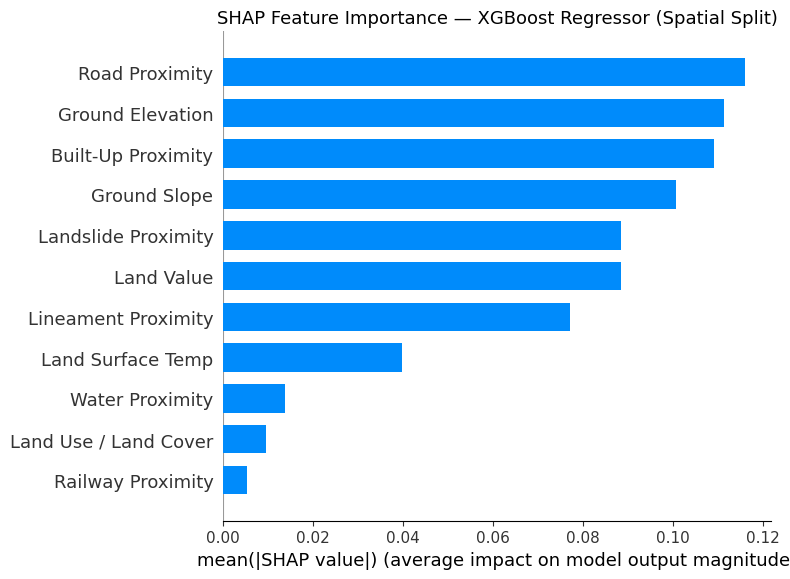

  Saved: shap_bar_plot.png


In [3]:
import shap
import matplotlib.pyplot as plt

# ---- CLEAN FEATURE NAMES FOR PLOTS ----
feature_names_clean = {
    "landslide_dist": "Landslide Proximity",
    "slope": "Ground Slope",
    "lulc": "Land Use / Land Cover",
    "elevation": "Ground Elevation",
    "road_dist": "Road Proximity",
    "builtup_dist": "Built-Up Proximity",
    "land_value": "Land Value",
    "water_dist": "Water Proximity",
    "lineament_dist": "Lineament Proximity",
    "lst": "Land Surface Temp",
    "railway_dist": "Railway Proximity"
}

X_shap_clean = X_shap.rename(columns=feature_names_clean)

# ============================================================
# PLOT 1: SHAP SUMMARY BAR PLOT (Mean Importance)
# ============================================================
print("Generating SHAP Summary Bar Plot...")
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap_clean, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — XGBoost Regressor (Spatial Split)", fontsize=13)
plt.tight_layout()
plt.savefig(r"D:\\Important\\Semester\\Semester X\\MTP\\LSI\\shap_bar_plot.png", dpi=300, bbox_inches='tight')
plt.show()
print("  Saved: shap_bar_plot.png")

In [4]:
import numpy as np
import pandas as pd

print("Calculating mean SHAP importance...")

# Mean absolute SHAP values
mean_shap = np.abs(shap_values).mean(axis=0)

# Convert to DataFrame
shap_importance = pd.DataFrame({
    "Feature": X_shap_clean.columns,
    "Mean_SHAP": mean_shap
})

# Sort descending
shap_importance = shap_importance.sort_values(by="Mean_SHAP", ascending=False)

# Normalize (optional but useful for comparison)
shap_importance["SHAP_norm"] = shap_importance["Mean_SHAP"] / shap_importance["Mean_SHAP"].sum()

# Print nicely
print("\nSHAP Feature Importance (Sorted):\n")

for i, row in enumerate(shap_importance.itertuples(), 1):
    print(f"{i:2d}. {row.Feature:25s}  |  SHAP: {row.Mean_SHAP:.6f}  |  Norm: {row.SHAP_norm:.4f}")

Calculating mean SHAP importance...

SHAP Feature Importance (Sorted):

 1. Road Proximity             |  SHAP: 0.116032  |  Norm: 0.1528
 2. Ground Elevation           |  SHAP: 0.111303  |  Norm: 0.1465
 3. Built-Up Proximity         |  SHAP: 0.109107  |  Norm: 0.1436
 4. Ground Slope               |  SHAP: 0.100711  |  Norm: 0.1326
 5. Landslide Proximity        |  SHAP: 0.088509  |  Norm: 0.1165
 6. Land Value                 |  SHAP: 0.088498  |  Norm: 0.1165
 7. Lineament Proximity        |  SHAP: 0.077068  |  Norm: 0.1015
 8. Land Surface Temp          |  SHAP: 0.039729  |  Norm: 0.0523
 9. Water Proximity            |  SHAP: 0.013660  |  Norm: 0.0180
10. Land Use / Land Cover      |  SHAP: 0.009590  |  Norm: 0.0126
11. Railway Proximity          |  SHAP: 0.005407  |  Norm: 0.0071



Generating SHAP Beeswarm Plot...


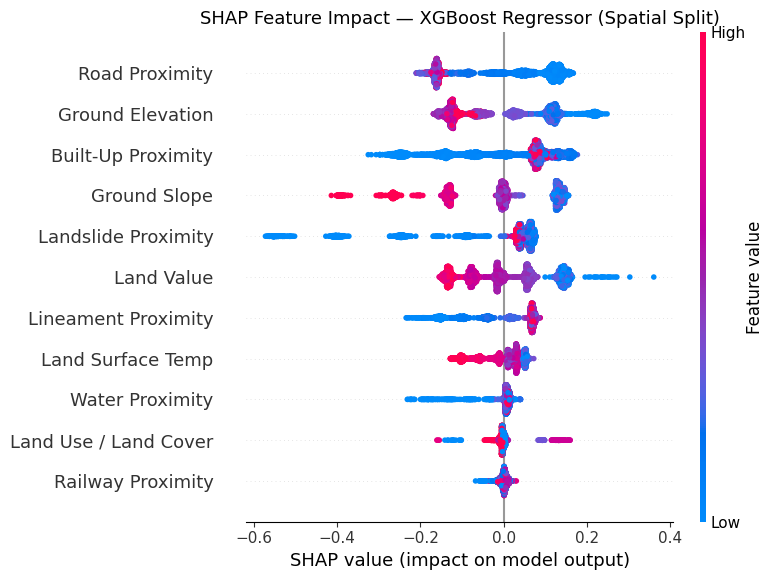

  Saved: shap_beeswarm_plot.png


In [5]:
# ============================================================
# PLOT 2: SHAP BEESWARM PLOT (Feature Impact Direction)
# ============================================================
print("\nGenerating SHAP Beeswarm Plot...")
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap_clean, show=False)
plt.title("SHAP Feature Impact — XGBoost Regressor (Spatial Split)", fontsize=13)
plt.tight_layout()
plt.savefig(r"D:\\Important\\Semester\\Semester X\\MTP\\LSI\\shap_beeswarm_plot.png", dpi=300, bbox_inches='tight')
plt.show()
print("  Saved: shap_beeswarm_plot.png")

In [6]:
import numpy as np
import pandas as pd

print("\nComputing SHAP distribution summary (beeswarm equivalent)...")

summary_data = []

for i, col in enumerate(X_shap_clean.columns):
    values = shap_values[:, i]
    
    mean_abs = np.mean(np.abs(values))   # importance
    mean_signed = np.mean(values)        # direction
    min_val = np.min(values)
    max_val = np.max(values)
    
    summary_data.append([
        col, mean_abs, mean_signed, min_val, max_val
    ])

# Convert to DataFrame
shap_summary = pd.DataFrame(summary_data, columns=[
    "Feature", "Mean_Abs_SHAP", "Mean_SHAP", "Min_SHAP", "Max_SHAP"
])

# Sort by importance
shap_summary = shap_summary.sort_values(by="Mean_Abs_SHAP", ascending=False)

# Print nicely
print("\nSHAP Feature Impact Summary (Beeswarm Equivalent):\n")

for i, row in enumerate(shap_summary.itertuples(), 1):
    direction = "↑ Positive" if row.Mean_SHAP > 0 else "↓ Negative"
    
    print(
        f"{i:2d}. {row.Feature:25s} | "
        f"Impact: {row.Mean_Abs_SHAP:.5f} | "
        f"Direction: {direction:10s} | "
        f"Range: [{row.Min_SHAP:.4f}, {row.Max_SHAP:.4f}]"
    )


Computing SHAP distribution summary (beeswarm equivalent)...

SHAP Feature Impact Summary (Beeswarm Equivalent):

 1. Road Proximity            | Impact: 0.11603 | Direction: ↑ Positive | Range: [-0.2103, 0.1670]
 2. Ground Elevation          | Impact: 0.11130 | Direction: ↓ Negative | Range: [-0.1687, 0.2481]
 3. Built-Up Proximity        | Impact: 0.10911 | Direction: ↑ Positive | Range: [-0.3251, 0.1768]
 4. Ground Slope              | Impact: 0.10071 | Direction: ↑ Positive | Range: [-0.4137, 0.1557]
 5. Landslide Proximity       | Impact: 0.08851 | Direction: ↓ Negative | Range: [-0.5718, 0.0776]
 6. Land Value                | Impact: 0.08850 | Direction: ↑ Positive | Range: [-0.1551, 0.3601]
 7. Lineament Proximity       | Impact: 0.07707 | Direction: ↑ Positive | Range: [-0.2343, 0.0876]
 8. Land Surface Temp         | Impact: 0.03973 | Direction: ↑ Positive | Range: [-0.1285, 0.0722]
 9. Water Proximity           | Impact: 0.01366 | Direction: ↑ Positive | Range: [-0.2315, 0.


Generating Feature Importance Comparison Plot...


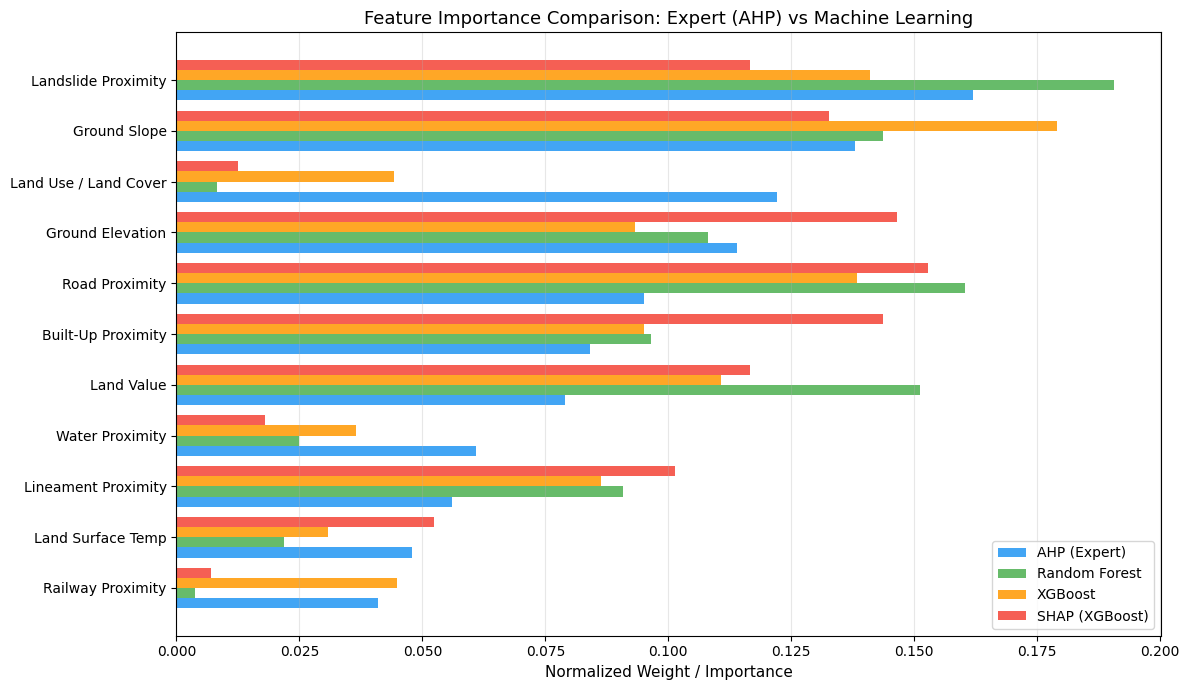

  Saved: feature_importance_comparison.png

✓ All SHAP visualizations complete.


In [20]:
# ============================================================
# PLOT 3: FEATURE IMPORTANCE COMPARISON (AHP vs RF vs XGB vs SHAP)
# ============================================================
print("\nGenerating Feature Importance Comparison Plot...")

# Prepare comparison data
comparison_df = pd.DataFrame({
    "Feature": [feature_names_clean[f] for f in feature_cols],
    "AHP": [ahp_weights[f] for f in feature_cols],
    "RF": [importance_df.set_index("Feature").loc[f, "RF_Importance"] for f in feature_cols],
    "XGBoost": [importance_df.set_index("Feature").loc[f, "XGB_Importance"] for f in feature_cols],
    "SHAP": [shap_df.set_index("Feature").loc[f, "SHAP_Normalized"] for f in feature_cols]
})

# Sort by AHP weight for consistent display
comparison_df = comparison_df.sort_values("AHP", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(comparison_df))
bar_height = 0.2

ax.barh(y_pos - 1.5*bar_height, comparison_df["AHP"], bar_height, label="AHP (Expert)", color="#2196F3", alpha=0.85)
ax.barh(y_pos - 0.5*bar_height, comparison_df["RF"], bar_height, label="Random Forest", color="#4CAF50", alpha=0.85)
ax.barh(y_pos + 0.5*bar_height, comparison_df["XGBoost"], bar_height, label="XGBoost", color="#FF9800", alpha=0.85)
ax.barh(y_pos + 1.5*bar_height, comparison_df["SHAP"], bar_height, label="SHAP (XGBoost)", color="#F44336", alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(comparison_df["Feature"], fontsize=10)
ax.set_xlabel("Normalized Weight / Importance", fontsize=11)
ax.set_title("Feature Importance Comparison: Expert (AHP) vs Machine Learning", fontsize=13)
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(r"D:\\Important\\Semester\\Semester X\\MTP\\LSI\\feature_importance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("  Saved: feature_importance_comparison.png")

print("\n✓ All SHAP visualizations complete.")

In [21]:
# ============================================================
# SHAP NUMERICAL IMPORTANCE (Mean Absolute SHAP)
# ============================================================
print("\nSHAP Feature Importance (Numerical Values):")

shap_importance = pd.DataFrame({
    "Feature": X_shap_clean.columns,
    "Mean_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values("Mean_SHAP", ascending=False)

print(shap_importance)


SHAP Feature Importance (Numerical Values):
                  Feature  Mean_SHAP
4          Road Proximity   0.116032
3        Ground Elevation   0.111303
5      Built-Up Proximity   0.109107
1            Ground Slope   0.100711
0     Landslide Proximity   0.088509
6              Land Value   0.088498
8     Lineament Proximity   0.077068
9       Land Surface Temp   0.039729
7         Water Proximity   0.013660
2   Land Use / Land Cover   0.009590
10      Railway Proximity   0.005407


In [22]:
# ============================================================
# SHAP RAW VALUES (For Beeswarm Equivalent)
# ============================================================
print("\nSHAP Raw Values (Sample):")

shap_raw_df = pd.DataFrame(shap_values, columns=X_shap_clean.columns)

print(shap_raw_df.head())  # preview


SHAP Raw Values (Sample):
   Landslide Proximity  Ground Slope  Land Use / Land Cover  Ground Elevation  \
0             0.056173      0.133239               0.002153         -0.111587   
1            -0.242602     -0.012484              -0.006436          0.010921   
2             0.068110      0.125849               0.003754          0.110335   
3             0.058355     -0.000685              -0.004470          0.133512   
4             0.060183     -0.000820               0.000445         -0.137820   

   Road Proximity  Built-Up Proximity  Land Value  Water Proximity  \
0        0.061190            0.049730    0.054550         0.009521   
1        0.027280           -0.156282   -0.139997         0.004384   
2        0.117050           -0.139417   -0.131530         0.009645   
3       -0.017887            0.132867   -0.063061         0.006927   
4        0.152681            0.117584    0.050333         0.009780   

   Lineament Proximity  Land Surface Temp  Railway Proximity  
0 

In [23]:
comparison_norm = comparison_df.copy()

for col in ["AHP", "RF", "XGBoost", "SHAP"]:
    comparison_norm[col] = comparison_norm[col] / comparison_norm[col].sum()

print("\nNormalized Comparison:")
print(comparison_norm)


Normalized Comparison:
                  Feature    AHP        RF   XGBoost      SHAP
10      Railway Proximity  0.041  0.003861  0.044807  0.007118
9       Land Surface Temp  0.048  0.021875  0.030750  0.052301
8     Lineament Proximity  0.056  0.090886  0.086410  0.101456
7         Water Proximity  0.061  0.024854  0.036538  0.017983
6              Land Value  0.079  0.151256  0.110747  0.116504
5      Built-Up Proximity  0.084  0.096468  0.095016  0.143634
4          Road Proximity  0.095  0.160384  0.138311  0.152752
3        Ground Elevation  0.114  0.108014  0.093236  0.146526
2   Land Use / Land Cover  0.122  0.008210  0.044226  0.012625
1            Ground Slope  0.138  0.143586  0.179032  0.132583
0     Landslide Proximity  0.162  0.190606  0.140927  0.116518
